#### Agglomerative Clustering
Kind of Hierarichal clustering, Agglomerative clustering is a bottom-up approach. It starts clustering by treating the individual data points as a single cluster then it is merged continuously based on similarity until it forms one big cluster containing all objects. It is good at identifying small clusters. 

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [17]:
dataset = pd.read_csv("../../..//data/Mall_Customers.csv")
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


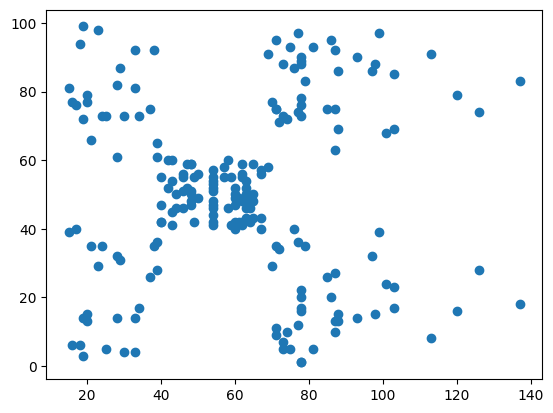

In [18]:
X = dataset[["Annual Income (k$)"]]
Y = dataset[["Spending Score (1-100)"]]
plt.scatter(X,Y)

## KMEANS

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\si

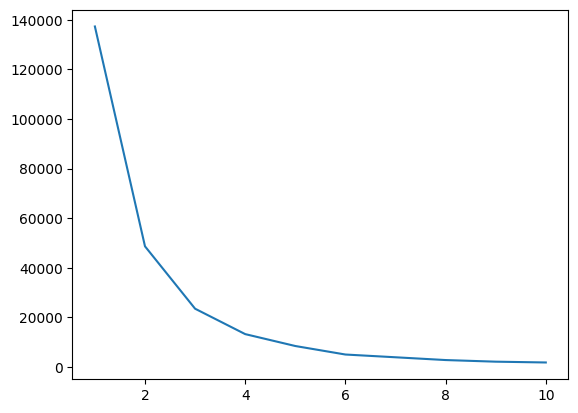

In [19]:
sse = []
for k in range(1,11):
    KM = KMeans(n_clusters=k)
    KM.fit_predict(X,Y)
    sse.append(KM.inertia_)

plt.plot(range(1,11),sse)

### Agglomerative

In [20]:
agg = AgglomerativeClustering(n_clusters=5,affinity="euclidean",linkage="ward")

In [21]:
prediction = agg.fit_predict(X)

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_agglomerative.py:1006: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [22]:
np.unique(prediction)

array([0, 1, 2, 3, 4], dtype=int64)

In [23]:
dataset["agg_cluster"] = prediction

In [24]:
df1 = dataset[dataset['agg_cluster'] == 0]
df2 = dataset[dataset['agg_cluster'] == 1]
df3 = dataset[dataset['agg_cluster'] == 2]
df4 = dataset[dataset['agg_cluster'] == 3]
df5 = dataset[dataset['agg_cluster'] == 4]

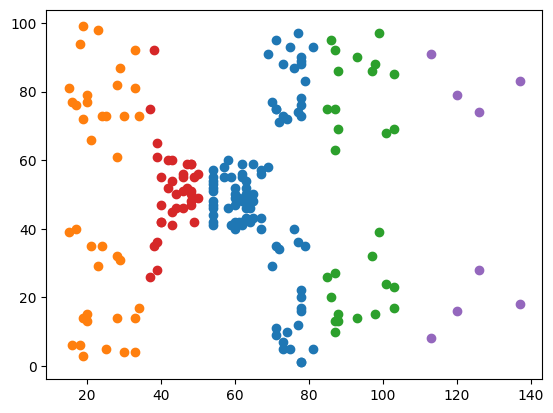

In [25]:
plt.scatter(df1["Annual Income (k$)"],df1["Spending Score (1-100)"])
plt.scatter(df2["Annual Income (k$)"],df2["Spending Score (1-100)"])
plt.scatter(df3["Annual Income (k$)"],df3["Spending Score (1-100)"])
plt.scatter(df4["Annual Income (k$)"],df4["Spending Score (1-100)"])
plt.scatter(df5["Annual Income (k$)"],df5["Spending Score (1-100)"])


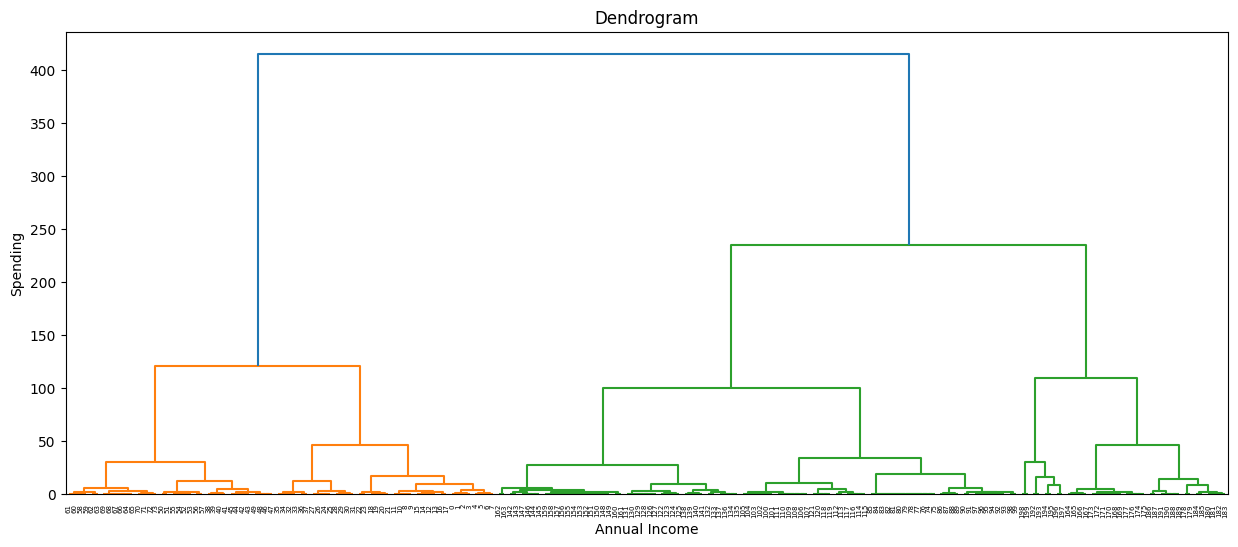

In [27]:
plt.figure(figsize=(15,6))
plt.title('Dendrogram')
plt.xlabel('Annual Income')
plt.ylabel('Spending')
#create linkage matrix
link_matrix = linkage(X,method='ward')
dnd = dendrogram(link_matrix)
plt.savefig("income_spending.png")
plt.show()